# Modulación M-PSK


In [1]:
#importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Se definen parámetros 
Num_intervalos=5
#Probabilidad del bits
p0 = 0.4
p1 = 1-p0
#Parámetros de modulación M-PSK
formato='unipolar' 
N=1# 0,1
M=8
n = int(np.log2(M))
Ts = 0.001
fs=1/Ts
# parámetros

#parámetros para la gráfica de señales
fmuestreo = 1000000
fc = 10000
Ac=1

#Número de bits de la secuencia a generar
Nun_sec=Num_intervalos*n

In [3]:
def generador_secuencia(n, p0, p1, semilla=None):
    # validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# ejemplo
secuencia = generador_secuencia(Nun_sec, p0, p1, semilla=42)
print(f"Secuencia generada: {secuencia}")

Secuencia generada: [1 1 1 1 0 1 1 1 0 1 0 1 1 1 1]


In [4]:
def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]

## Convertidor de Datos M-PSK

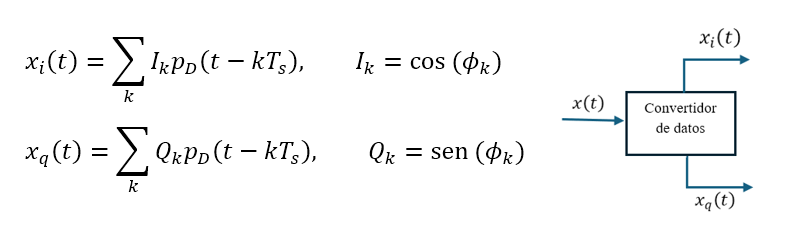

In [5]:
def convertidor_datos_psk(bits, M=4, N=0):
    n = int(np.log2(M))
    
    # asegurar múltiplo de n
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    # agrupar bits
    grupos = bits.reshape(-1, n)
    
    # generar código Gray
    gray = gray_code(n)
    
    # mapping: binario -> índice Gray
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # convertir grupos a índices b_k
    bk = [mapping[tuple(grupo)] for grupo in grupos]
    bk = np.array(bk)
    
    # calcular fases: φ_k = π(2*b_k + N)/M
    phi_k = np.pi * (2*bk + N) / M
    
    # calcular componentes I_k y Q_k
    Ik = np.cos(phi_k)
    Qk = np.sin(phi_k)
    
    # crear tabla de correspondencia
    tabla = {}
    for i, code in enumerate(gray):
        b = i
        phi = np.pi * (2*b + N) / M
        I = np.cos(phi)
        Q = np.sin(phi)
        tabla[code] = {'bk': b, 'phi_k': phi, 'Ik': I, 'Qk': Q}
    
    return Ik, Qk, bk, tabla


# Convertir datos
Ik, Qk, bk, tabla = convertidor_datos_psk(secuencia, M, N)

# Mostrar tabla de correspondencia
print("Tabla de correspondencia M-PSK:")
print(f"{'Gray':<10} {'bk':<5} {'phi_k':<15} {'Ik=cos(phi_k)':<15} {'Qk=sen(phi_k)':<15}")
print("-" * 70)
for gray_code_str, valores in tabla.items():
    print(f"{gray_code_str:<10} {valores['bk']:<5} {valores['phi_k']:<15.4f} {valores['Ik']:<15.4f} {valores['Qk']:<15.4f}")

print(f"\nPrimeros 20 símbolos Ik: {Ik[:20]}")
print(f"Primeros 20 símbolos Qk: {Qk[:20]}")

Tabla de correspondencia M-PSK:
Gray       bk    phi_k           Ik=cos(phi_k)   Qk=sen(phi_k)  
----------------------------------------------------------------------
000        0     0.3927          0.9239          0.3827         
001        1     1.1781          0.3827          0.9239         
011        2     1.9635          -0.3827         0.9239         
010        3     2.7489          -0.9239         0.3827         
110        4     3.5343          -0.9239         -0.3827        
111        5     4.3197          -0.3827         -0.9239        
101        6     5.1051          0.3827          -0.9239        
100        7     5.8905          0.9239          -0.3827        

Primeros 20 símbolos Ik: [-0.38268343  0.38268343 -0.92387953  0.38268343 -0.38268343]
Primeros 20 símbolos Qk: [-0.92387953 -0.92387953 -0.38268343 -0.92387953 -0.92387953]



# La señal modulada M-PSK se puede expresar como:

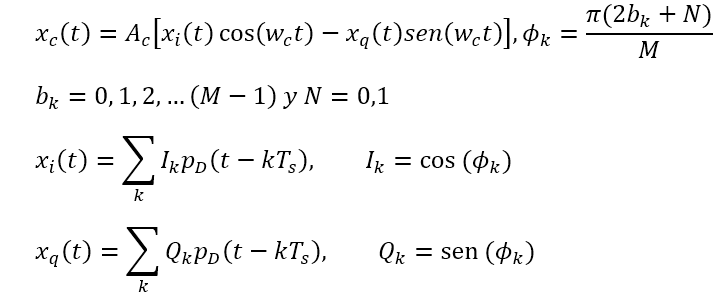

In [6]:
def pulso_rectangular(t, Ts, fmuestreo):
    """Genera un pulso rectangular de duración Ts"""
    eps = 1/(2*fmuestreo)
    return np.where((t >= -eps) & (t < Ts - eps), 1.0, 0.0)


def generar_xi(simbolos_I, Ts, fmuestreo):
    """
    Genera la señal en fase xi(t) = Σ_k I_k · p_D(t - k·T_s)
    """
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos_I) * Ns) / fmuestreo
    xi_t = np.zeros_like(t, dtype=float)
    
    for k, I_k in enumerate(simbolos_I):
        xi_t += I_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    
    return t, xi_t


def generar_xq(simbolos_Q, Ts, fmuestreo):
    """
    Genera la señal en cuadratura xq(t) = Σ_k Q_k · p_D(t - k·T_s)
    """
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos_Q) * Ns) / fmuestreo
    xq_t = np.zeros_like(t, dtype=float)
    
    for k, Q_k in enumerate(simbolos_Q):
        xq_t += Q_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    
    return t, xq_t


# Generar señales para los primeros 20 símbolos
num_simbolos = 20
t, x_i = generar_xi(Ik[:num_simbolos], Ts, fmuestreo)
_, x_q = generar_xq(Qk[:num_simbolos], Ts, fmuestreo)

# Pulso rectangular (para graficar)
pulso_rect = pulso_rectangular(t, Ts, fmuestreo)

# Portadoras
wc = 2 * np.pi * fc
portadora_cos = np.cos(wc * t)
portadora_sin = -np.sin(wc * t)

# Productos de señales con portadoras
xi_cos = x_i * portadora_cos
xq_sin = -x_q * np.sin(wc * t)

# Señal modulada: x_c(t) = A_c[x_q(t)cos(w_c·t) - x_i(t)sin(w_c·t)]
x_c = Ac * (x_i * portadora_cos - x_q * np.sin(wc * t))

print(f"Señales generadas exitosamente para {num_simbolos} símbolos")
print(f"Duración total: {t[-1]:.6f} segundos")
print(f"Número de muestras: {len(t)}")

Señales generadas exitosamente para 20 símbolos
Duración total: 0.004999 segundos
Número de muestras: 5000


In [7]:
# Obtener la secuencia de códigos Gray para cada símbolo
def obtener_gray_secuencia(bits, M):
    """Retorna la secuencia de códigos Gray correspondientes a los símbolos"""
    n = int(np.log2(M))
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    grupos = bits.reshape(-1, n)
    gray = gray_code(n)
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # Obtener códigos Gray para cada símbolo
    gray_secuencia = []
    for grupo in grupos:
        # Encontrar el código Gray correspondiente
        for code in gray:
            if mapping[tuple(int(b) for b in code)] == mapping[tuple(grupo)]:
                gray_secuencia.append(code)
                break
    
    return gray_secuencia

# Obtener secuencia de códigos Gray
gray_secuencia = obtener_gray_secuencia(secuencia, M)
print(f"dsecuencia Gray: {gray_secuencia[:num_simbolos]}")

dsecuencia Gray: ['111', '101', '110', '101', '111']


Secuencia generada: [1 1 1 1 0 1 1 1 0 1 0 1 1 1 1]

Primeros 20 símbolos Ik: [-0.38268343  0.38268343 -0.92387953  0.38268343 -0.38268343]
Primeros 20 símbolos Qk: [-0.92387953 -0.92387953 -0.38268343 -0.92387953 -0.92387953]
Tabla de correspondencia M-PSK:
Gray       bk    phi_k           Ik=cos(phi_k)   Qk=sen(phi_k)  
----------------------------------------------------------------------
000        0     0.3927          0.9239          0.3827         
001        1     1.1781          0.3827          0.9239         
011        2     1.9635          -0.3827         0.9239         
010        3     2.7489          -0.9239         0.3827         
110        4     3.5343          -0.9239         -0.3827        
111        5     4.3197          -0.3827         -0.9239        
101        6     5.1051          0.3827          -0.9239        
100        7     5.8905          0.9239          -0.3827        


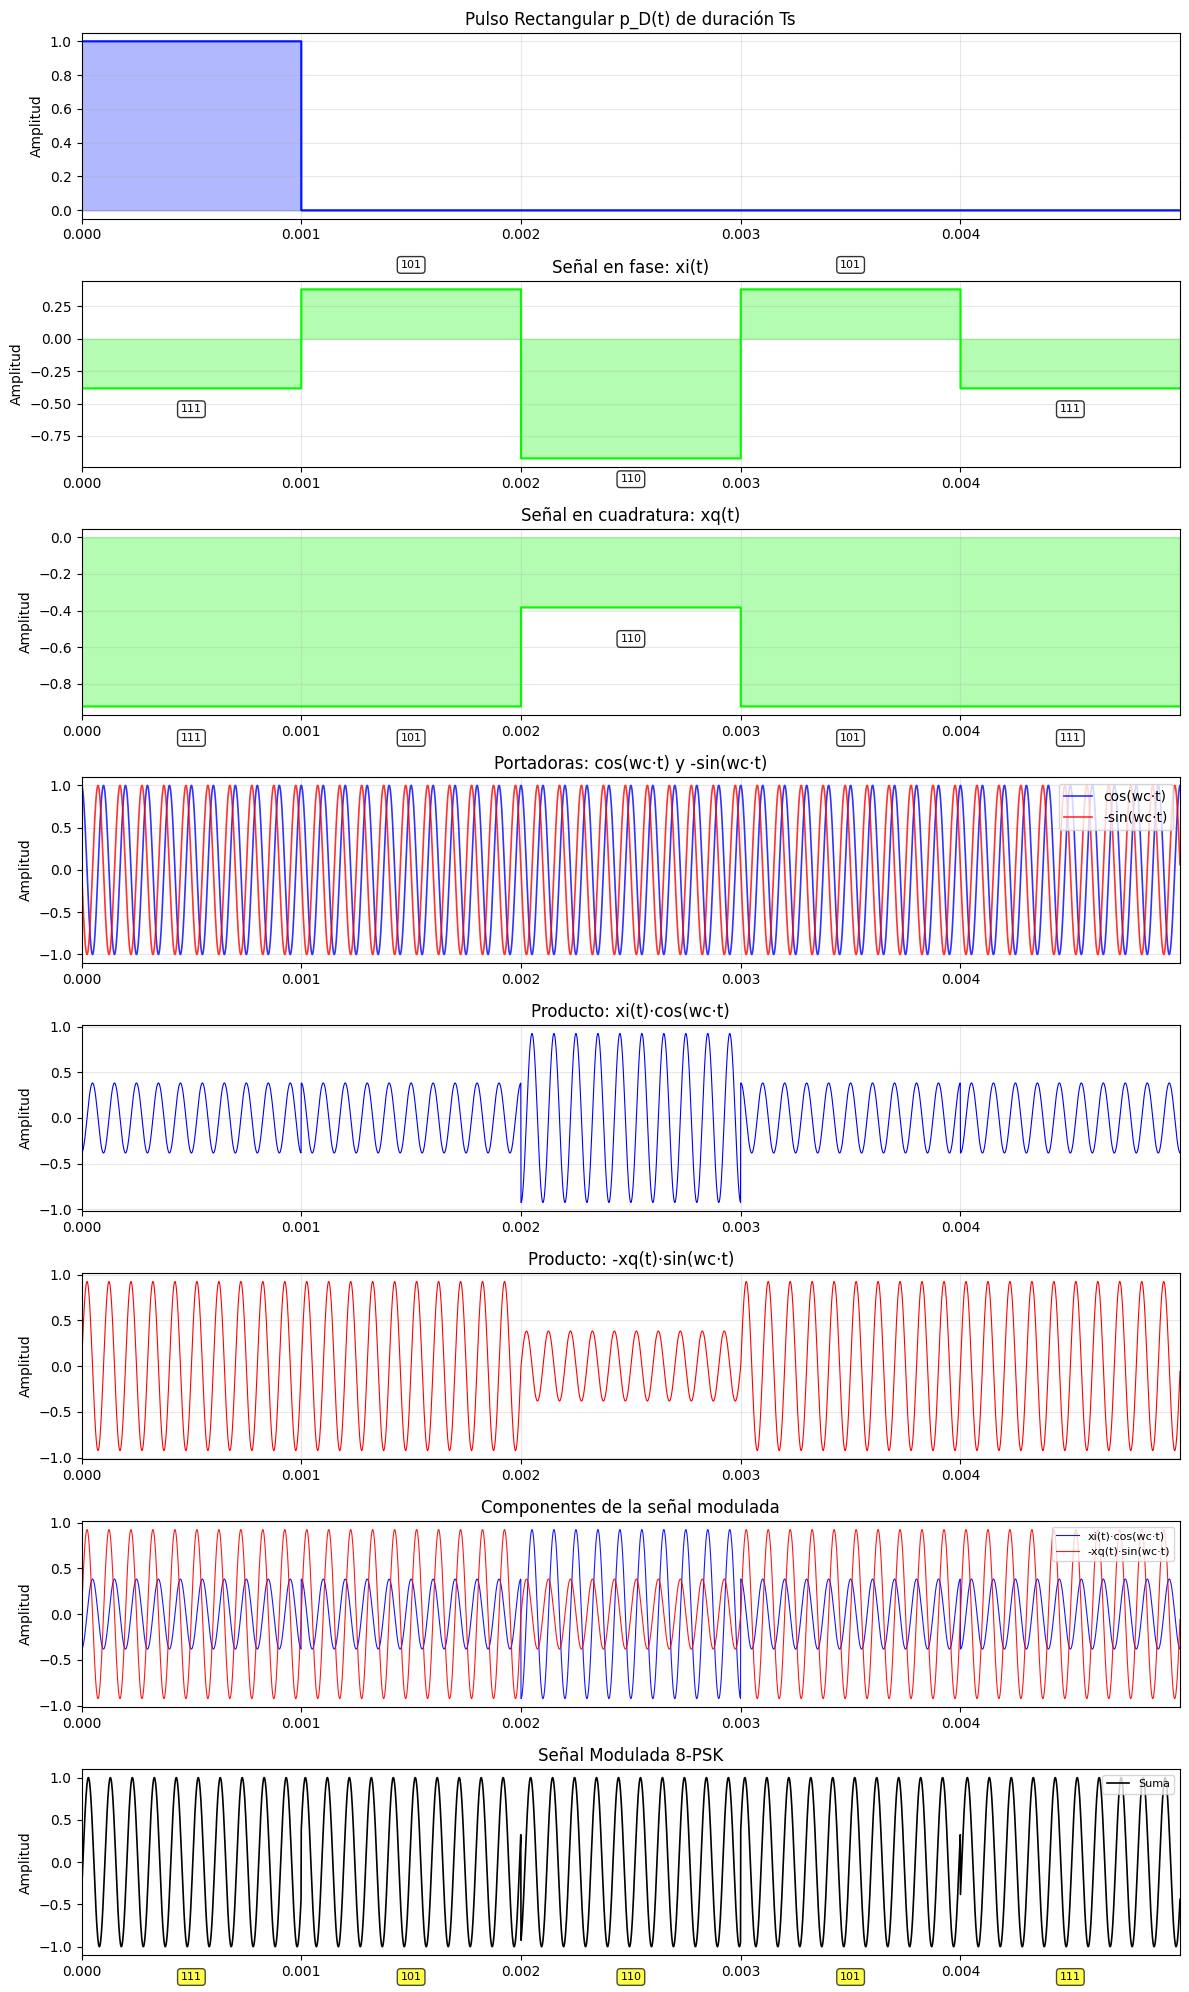

In [8]:

print(f"Secuencia generada: {secuencia}")
print(f"\nPrimeros 20 símbolos Ik: {Ik[:20]}")
print(f"Primeros 20 símbolos Qk: {Qk[:20]}")
# Mostrar tabla de correspondencia
print("Tabla de correspondencia M-PSK:")
print(f"{'Gray':<10} {'bk':<5} {'phi_k':<15} {'Ik=cos(phi_k)':<15} {'Qk=sen(phi_k)':<15}")
print("-" * 70)
for gray_code_str, valores in tabla.items():
    print(f"{gray_code_str:<10} {valores['bk']:<5} {valores['phi_k']:<15.4f} {valores['Ik']:<15.4f} {valores['Qk']:<15.4f}")

    
# Gráficos de las formas de onda con anotaciones de códigos Gray
plt.figure(figsize=(12, 20))

# 1. Pulso rectangular
plt.subplot(8, 1, 1)
plt.step(t, pulso_rect, where='post', color='#0015FA', linewidth=1.5)
plt.fill_between(t, pulso_rect, color='#0015FA', alpha=0.3)
plt.title("Pulso Rectangular p_D(t) de duración Ts")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 2. Señal en fase xi(t) con códigos Gray
ax2 = plt.subplot(8, 1, 2)
plt.step(t, x_i, where='post', color='#09F700', linewidth=1.5)
plt.fill_between(t, x_i, color='#09F700', alpha=0.3)
plt.title("Señal en fase: xi(t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray
for k in range(min(len(gray_secuencia), num_simbolos)):
    if k < len(Ik):
        t_pos = (k + 0.5) * Ts  # Posición en el centro del intervalo
        y_pos = Ik[k] + 0.15 if Ik[k] >= 0 else Ik[k] - 0.2  # Posición vertical
        plt.text(t_pos, y_pos, gray_secuencia[k], ha='center', va='bottom', 
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 3. Señal en cuadratura xq(t) con códigos Gray
ax3 = plt.subplot(8, 1, 3)
plt.step(t, x_q, where='post', color='#09F700', linewidth=1.5)
plt.fill_between(t, x_q, color='#09F700', alpha=0.3)
plt.title("Señal en cuadratura: xq(t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray
for k in range(min(len(gray_secuencia), num_simbolos)):
    if k < len(Qk):
        t_pos = (k + 0.5) * Ts
        y_pos = Qk[k] + 0.15 if Qk[k] >= 0 else Qk[k] - 0.2
        plt.text(t_pos, y_pos, gray_secuencia[k], ha='center', va='bottom',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 4. Portadoras: cos(wc·t) y -sin(wc·t)
plt.subplot(8, 1, 4)
plt.plot(t, portadora_cos, color='blue', linewidth=1.2, label='cos(wc·t)', alpha=0.8)
plt.plot(t, portadora_sin, color='red', linewidth=1.2, label='-sin(wc·t)', alpha=0.8)
plt.title("Portadoras: cos(wc·t) y -sin(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.xlim([0, t[-1]])

# 5. Producto xi(t)cos(wc·t)
plt.subplot(8, 1, 5)
plt.plot(t, xi_cos, color='blue', linewidth=0.8)
plt.title("Producto: xi(t)·cos(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 6. Producto -xq(t)sin(wc·t)
plt.subplot(8, 1, 6)
plt.plot(t, xq_sin, color='red', linewidth=0.8)
plt.title("Producto: -xq(t)·sin(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 7. Suma de productos (componentes de xc(t))
plt.subplot(8, 1, 7)
plt.plot(t, xi_cos, color='blue', linewidth=0.8, alpha=0.9, label='xi(t)·cos(wc·t)')
plt.plot(t, xq_sin, color='red', linewidth=0.8, alpha=0.9, label='-xq(t)·sin(wc·t)')
plt.title(f"Componentes de la señal modulada")
plt.ylabel('Amplitud')
plt.legend(loc='upper right', fontsize=8)
plt.xlim([0, t[-1]])

# 8. Señal modulada con códigos Gray
ax8 = plt.subplot(8, 1, 8)
plt.plot(t, xi_cos + xq_sin, color='#000000', linewidth=1.2, label='Suma')
plt.title(f"Señal Modulada {M}-PSK")
plt.ylabel('Amplitud')
plt.legend(loc='upper right', fontsize=8)
plt.xlim([0, t[-1]])
# Añadir códigos Gray en la señal modulada (abajo)
y_max = np.max(xi_cos + xq_sin)
y_min = np.min(xi_cos + xq_sin)
y_range = y_max - y_min
for k in range(min(len(gray_secuencia), num_simbolos)):
    t_pos = (k + 0.5) * Ts
    # Posicionar en la parte inferior del gráfico
    y_pos = y_min - 0.15 * y_range
    plt.text(t_pos, y_pos, gray_secuencia[k], ha='center', va='top',
            fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# Variables estadísticas para el cálculo de la DEP

In [9]:
# Se obtiene la probabilidad de los símbolos
# p(gray) = p(b_k) = p(φ_k) = p(I_k = cos(φ_k)) = p(Q_k = sen(φ_k))

def get_prob_simbolo(bits, p0, p1):
    """Calcula la probabilidad de un código Gray dado p0 y p1"""
    prob = 1
    for b in bits:
        if b == '0':
            prob *= p0
        else:
            prob *= p1
    return prob

# Crear diccionario de probabilidades para φ_k, I_k y Q_k
# Usando la tabla de correspondencia ya generada
P_phi_k = {}
P_Ik = {}
P_Qk = {}

for gray_code_str, valores in tabla.items():
    prob = get_prob_simbolo(gray_code_str, p0, p1)
    phi_k = valores['phi_k']
    Ik_val = valores['Ik']
    Qk_val = valores['Qk']
    
    P_phi_k[phi_k] = prob
    P_Ik[Ik_val] = prob
    P_Qk[Qk_val] = prob

# Imprimir tabla de probabilidades
print("Tabla de probabilidades:")
print(f"{'Gray':<10} {'φ_k':<15} {'I_k':<15} {'Q_k':<15} {'p(φ_k)':<10}")
print("-" * 75)
for gray_code_str, valores in tabla.items():
    prob = get_prob_simbolo(gray_code_str, p0, p1)
    print(f"{gray_code_str:<10} {valores['phi_k']:<15.4f} {valores['Ik']:<15.4f} {valores['Qk']:<15.4f} {prob:<10.4f}")

Tabla de probabilidades:
Gray       φ_k             I_k             Q_k             p(φ_k)    
---------------------------------------------------------------------------
000        0.3927          0.9239          0.3827          0.0640    
001        1.1781          0.3827          0.9239          0.0960    
011        1.9635          -0.3827         0.9239          0.1440    
010        2.7489          -0.9239         0.3827          0.0960    
110        3.5343          -0.9239         -0.3827         0.1440    
111        4.3197          -0.3827         -0.9239         0.2160    
101        5.1051          0.3827          -0.9239         0.1440    
100        5.8905          0.9239          -0.3827         0.0960    


# Media de I_k
$$m_i = \overline{I_k} = \overline{\cos(\phi_k)} = \sum_{i=1}^{M} \cos(\phi_k)_i \cdot p(\phi_k)_i$$

In [10]:
# Calcular la media de I_k
# m_i = Σ I_k * p(I_k) = Σ cos(φ_k) * p(φ_k)
def get_media(data):
    """Calcula el valor medio dado un diccionario {valor: probabilidad}"""
    media = 0
    for valor, prob in data.items():
        media += valor * prob
    return media

m_i = get_media(P_Ik)
print(f'Media de I_k: m_i = {m_i:.6f}')

Media de I_k: m_i = -0.119832


# Media de Q_k
$$m_q = \overline{Q_k} = \overline{\sin(\phi_k)} = \sum_{i=1}^{M} \sin(\phi_k)_i \cdot p(\phi_k)_i$$

In [11]:
# Calcular la media de Q_k
# m_q = Σ Q_k * p(Q_k) = Σ sen(φ_k) * p(φ_k)
m_q = get_media(P_Qk)
print(f'Media de Q_k: m_q = {m_q:.6f}')

Media de Q_k: m_q = -0.230173


# Varianza de I_k
$$\sigma_i^2 = \overline{I_k^2} - \overline{I_k}^2 = \sum_{i=1}^{M} \cos^2(\phi_k)_i \cdot p(\phi_k)_i - m_i^2$$

In [12]:
# Calcular la varianza de I_k
# σ_i² = E[I_k²] - (E[I_k])² = Σ I_k² * p(I_k) - m_i²
def get_rms(data):
    """Calcula el valor cuadrático medio dado un diccionario {valor: probabilidad}"""
    rms = 0
    for valor, prob in data.items():
        rms += valor**2 * prob
    return rms

sigma_i2 = get_rms(P_Ik) - m_i**2
print(f'Varianza de I_k: σ_i² = {sigma_i2:.6f}')

Varianza de I_k: σ_i² = 0.414930


# Varianza de Q_k
$$\sigma_q^2 = \overline{Q_k^2} - \overline{Q_k}^2 = \sum_{i=1}^{M} \sin^2(\phi_k)_i \cdot p(\phi_k)_i - m_q^2$$

In [13]:
# Calcular la varianza de Q_k
# σ_q² = E[Q_k²] - (E[Q_k])² = Σ Q_k² * p(Q_k) - m_q²
sigma_q2 = get_rms(P_Qk) - m_q**2
print(f'Varianza de Q_k: σ_q² = {sigma_q2:.6f}')

Varianza de Q_k: σ_q² = 0.435790


# Densidad Espectral de Potencia (DEP) M-PSK

## Ecuaciones de la DEP

**Densidad espectral de las señales de banda base:**

$$G_i(f) = \sigma_i^2 f_s |P_D(f)|^2 + m_i^2 \delta(f)$$

$$G_q(f) = \sigma_q^2 f_s |P_D(f)|^2 + m_q^2 \delta(f)$$

**Para pulso rectangular:**

$$|P_D(f)|^2 = \frac{1}{f_s^2} \text{sinc}^2\left(\frac{f}{f_s}\right)$$

**Densidad espectral de la señal modulada:**

$$G_c(f) = \frac{A_c^2}{4} \left[G_i(f-f_c) + G_i(f+f_c) + G_q(f-f_c) + G_q(f+f_c)\right]$$

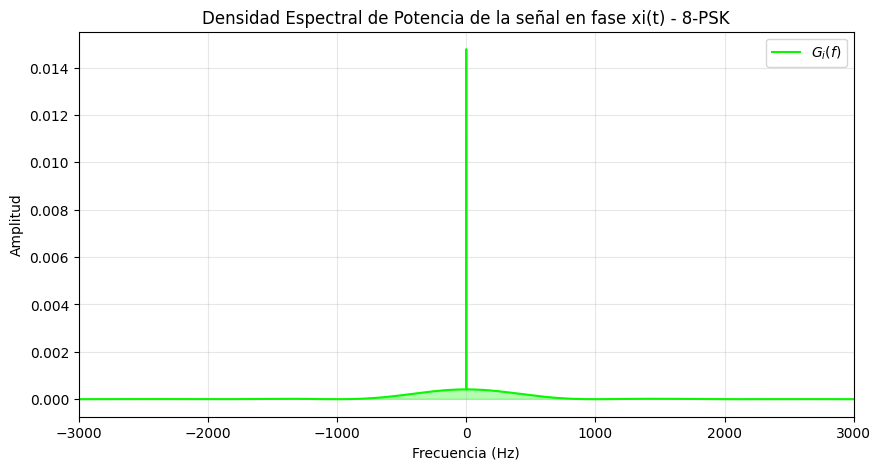

Componente continua máxima de G_i(f): 4.149295e-04
Componente discreta de G_i(f): 1.435980e-02


In [14]:
# Vector de frecuencias
f = np.linspace(-20000, 20000, 200000)

# Función delta de Dirac (aproximada)
def delta(arg):
    """Aproximación de la función delta de Dirac"""
    delta_signal = np.zeros_like(f)
    idx = np.argmin(np.abs(arg))
    delta_signal[idx] = 1
    return delta_signal

# Transformada de Fourier del pulso rectangular
# |P_D(f)|² = (1/fs²) * sinc²(f/fs)
P_D_squared = (1 / fs**2) * np.sinc(f / fs)**2

# Densidad espectral de potencia de la señal en fase
# G_i(f) = σ_i² * fs * |P_D(f)|² + m_i² * δ(f)
G_i_continua = sigma_i2 * fs * P_D_squared
G_i_discreta = m_i**2 * delta(f)
G_i = G_i_continua + G_i_discreta

# Gráfica de G_i(f)
plt.figure(figsize=(10, 5))
plt.plot(f, G_i, color='#09F700', label=r'$G_i(f)$')
plt.fill_between(f, G_i, color='#09F700', alpha=0.3)
plt.title(f"Densidad Espectral de Potencia de la señal en fase xi(t) - {M}-PSK")
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([-3*fs, 3*fs])
plt.show()

print(f"Componente continua máxima de G_i(f): {np.max(G_i_continua):.6e}")
print(f"Componente discreta de G_i(f): {m_i**2:.6e}")

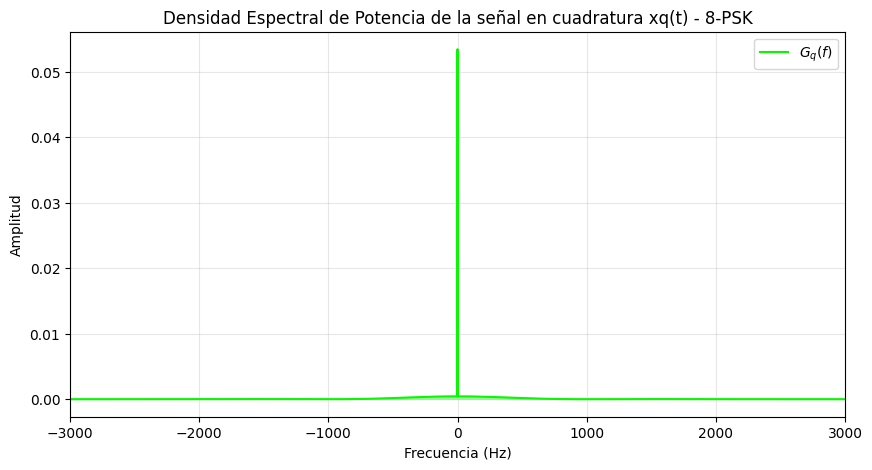

Componente continua máxima de G_q(f): 4.357901e-04
Componente discreta de G_q(f): 5.297945e-02


In [15]:
# Densidad espectral de potencia de la señal en cuadratura
# G_q(f) = σ_q² * fs * |P_D(f)|² + m_q² * δ(f)
G_q_continua = sigma_q2 * fs * P_D_squared
G_q_discreta = m_q**2 * delta(f)
G_q = G_q_continua + G_q_discreta

# Gráfica de G_q(f)
plt.figure(figsize=(10, 5))
plt.plot(f, G_q, color='#09F700', label=r'$G_q(f)$')
plt.fill_between(f, G_q, color='#09F700', alpha=0.3)
plt.title(f"Densidad Espectral de Potencia de la señal en cuadratura xq(t) - {M}-PSK")
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([-3*fs, 3*fs])
plt.show()

print(f"Componente continua máxima de G_q(f): {np.max(G_q_continua):.6e}")
print(f"Componente discreta de G_q(f): {m_q**2:.6e}")

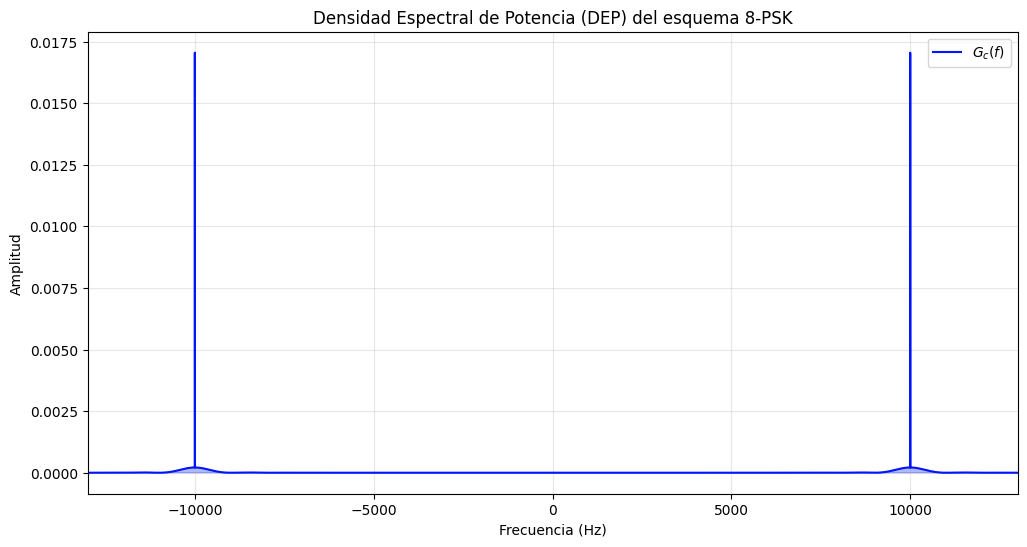


Resumen de la DEP:
Frecuencia de la portadora: fc = 10000 Hz
Frecuencia de símbolo: fs = 1000.0 Hz
Potencia máxima de G_c(f): 1.704749e-02


In [16]:
# Densidad espectral de potencia de la señal modulada
# G_c(f) = (A_c²/4) * [G_i(f-fc) + G_i(f+fc) + G_q(f-fc) + G_q(f+fc)]

# Calcular |P_D(f±fc)|² para las frecuencias trasladadas
P_D_squared_plus = (1 / fs**2) * np.sinc((f - fc) / fs)**2
P_D_squared_minus = (1 / fs**2) * np.sinc((f + fc) / fs)**2

# G_i(f±fc)
G_i_plus_continua = sigma_i2 * fs * P_D_squared_plus
G_i_plus_discreta = m_i**2 * delta(f - fc)
G_i_plus = G_i_plus_continua + G_i_plus_discreta

G_i_minus_continua = sigma_i2 * fs * P_D_squared_minus
G_i_minus_discreta = m_i**2 * delta(f + fc)
G_i_minus = G_i_minus_continua + G_i_minus_discreta

# G_q(f±fc)
G_q_plus_continua = sigma_q2 * fs * P_D_squared_plus
G_q_plus_discreta = m_q**2 * delta(f - fc)
G_q_plus = G_q_plus_continua + G_q_plus_discreta

G_q_minus_continua = sigma_q2 * fs * P_D_squared_minus
G_q_minus_discreta = m_q**2 * delta(f + fc)
G_q_minus = G_q_minus_continua + G_q_minus_discreta

# G_c(f) total
G_c = (Ac**2 / 4) * (G_i_plus + G_i_minus + G_q_plus + G_q_minus)

# Gráfica de G_c(f)
plt.figure(figsize=(12, 6))
plt.plot(f, G_c, color='#0015FA', label=r'$G_c(f)$', linewidth=1.5)
plt.fill_between(f, G_c, color='#0015FA', alpha=0.3)
titulo = f"Densidad Espectral de Potencia (DEP) del esquema {M}-PSK"
plt.title(titulo)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([-fc - 3*fs, fc + 3*fs])
plt.show()

print(f"\nResumen de la DEP:")
print(f"Frecuencia de la portadora: fc = {fc} Hz")
print(f"Frecuencia de símbolo: fs = {fs} Hz")
print(f"Potencia máxima de G_c(f): {np.max(G_c):.6e}")

# Diagrama de Constelación M-PSK

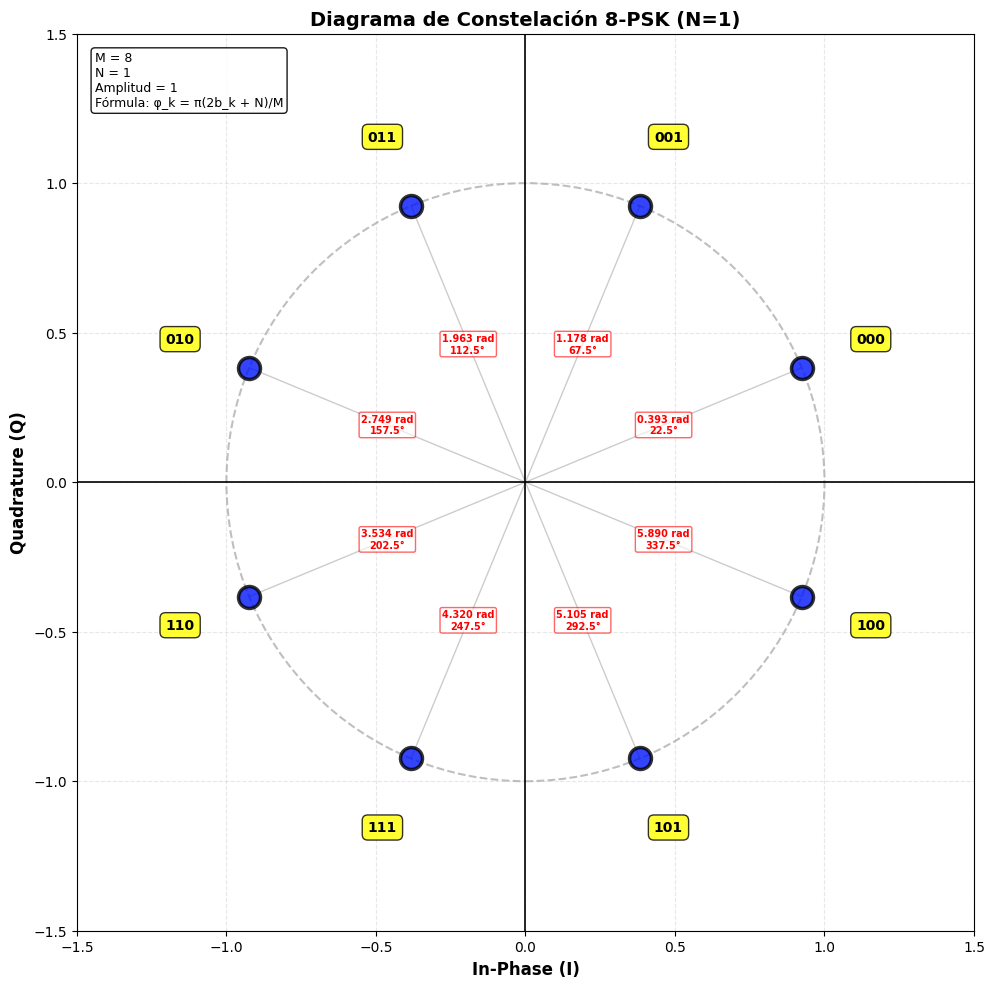

Diagrama de constelación 8-PSK generado
Número de puntos de señal: 8

Coordenadas de constelación:
  000: I=0.9239, Q=0.3827, φ=0.3927 rad (22.50°)
  001: I=0.3827, Q=0.9239, φ=1.1781 rad (67.50°)
  011: I=-0.3827, Q=0.9239, φ=1.9635 rad (112.50°)
  010: I=-0.9239, Q=0.3827, φ=2.7489 rad (157.50°)
  110: I=-0.9239, Q=-0.3827, φ=3.5343 rad (202.50°)
  111: I=-0.3827, Q=-0.9239, φ=4.3197 rad (247.50°)
  101: I=0.3827, Q=-0.9239, φ=5.1051 rad (292.50°)
  100: I=0.9239, Q=-0.3827, φ=5.8905 rad (337.50°)


In [17]:
# Generar todos los puntos de la constelación M-PSK
constelacion_I = []
constelacion_Q = []
constelacion_phi = []
labels_constelacion = []

# Para cada código Gray, obtener I_k, Q_k y φ_k
for gray_code_str, valores in tabla.items():
    constelacion_I.append(valores['Ik'])
    constelacion_Q.append(valores['Qk'])
    constelacion_phi.append(valores['phi_k'])
    labels_constelacion.append(gray_code_str)

# Crear diagrama de constelación
fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar círculo unitario
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
ax.add_patch(circle)

# Dibujar puntos de la constelación
ax.scatter(constelacion_I, constelacion_Q, s=250, c='#0015FA', marker='o', 
           edgecolors='black', linewidths=2.5, zorder=3, alpha=0.8)

# Dibujar líneas desde el origen a cada punto
for I, Q in zip(constelacion_I, constelacion_Q):
    ax.plot([0, I], [0, Q], 'gray', linestyle='-', linewidth=1, alpha=0.4, zorder=1)

# Agregar etiquetas de códigos Gray y ángulos
for i, (I, Q, phi, label) in enumerate(zip(constelacion_I, constelacion_Q, constelacion_phi, labels_constelacion)):
    # Posición de la etiqueta (un poco más alejada del punto)
    offset_factor = 1.25
    label_I = I * offset_factor
    label_Q = Q * offset_factor
    
    # Etiqueta con código Gray
    ax.annotate(label, (I, Q), xytext=(label_I, label_Q),
                ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8))
    
    # Etiqueta con ángulo (en radianes)
    angle_text = f'{phi:.3f} rad\n{np.degrees(phi):.1f}°'
    ax.text(I * 0.5, Q * 0.5, angle_text, ha='center', va='center',
            fontsize=7, color='red', weight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, edgecolor='red'))

# Configuración de ejes
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.2)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlabel('In-Phase (I)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quadrature (Q)', fontsize=12, fontweight='bold')
ax.set_title(f'Diagrama de Constelación {M}-PSK (N={N})', fontsize=14, fontweight='bold')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_aspect('equal', adjustable='box')

# Agregar información adicional
info_text = f'M = {M}\nN = {N}\nAmplitud = 1\nFórmula: φ_k = π(2b_k + N)/M'
ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

plt.tight_layout()
plt.show()

print(f"Diagrama de constelación {M}-PSK generado")
print(f"Número de puntos de señal: {len(constelacion_I)}")
print(f"\nCoordenadas de constelación:")
for gray, I, Q, phi in zip(labels_constelacion, constelacion_I, constelacion_Q, constelacion_phi):
    print(f"  {gray}: I={I:.4f}, Q={Q:.4f}, φ={phi:.4f} rad ({np.degrees(phi):.2f}°)")